# Object Detection Using RF-DETR (Part-2)

### Welcome to the 9th Lab of 42028: Deep Learning and CNN!

This tutorial is based on the [RF-DETR RoboFlow Notebook](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-finetune-rf-detr-on-detection-dataset.ipynb). This notebook shows How to Train RF-DETR object detection method on **Custom dataset, or your own custom objects**.

This code notebook is written and adapted by **Dr. Nabin Sharma**, University of Technology Sydney for academic teaching purposes only.

### Steps Covered in this Tutorial

In this tutorial, we will walk through the steps required to train RF-DETR on your custom objects.

To train our detector we take the following steps:

* Install RF-DETR dependencies
* Download and Prepare custom object detection data in Coco format
* Try RF-DETR on pre-trained model
* Fine-tuning RF-DETR on custom dataset
* Evaluate  performance
* Run inference on test images


## Introduction to RF-DETR Object Detector:
---

RF-DETR is a real-time, transformer-based object detection model architecture developed by Roboflow and released under the Apache 2.0 license.

![rf-detr-coco-rf100-vl-8](https://media.roboflow.com/rf-detr/charts.png)

RF-DETR is the first real-time model to exceed 60 AP on the [Microsoft COCO benchmark](https://cocodataset.org/#home) alongside competitive performance at base sizes. It also achieves state-of-the-art performance on [RF100-VL](https://github.com/roboflow/rf100-vl), an object detection benchmark that measures model domain adaptability to real world problems. RF-DETR is comparable speed to current real-time objection models.

![rf-detr-coco-results-2](https://media.roboflow.com/rf-detr/example_grid.png)

RF-DETR is small enough to run on the edge, making it an ideal model for deployments that need both strong accuracy and real-time performance.

## Environment setup

**NOTE** : Use A100 GPU if available this will help to train faster around ~4min per epoch. With T4 GPU it would take around ~1hr per epoch for training!

#### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, if A100 is not available and then click `Save`.

In [2]:
!nvidia-smi

Tue Apr 21 11:04:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   25C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install dependencies

In [3]:
# !pip install -q rfdetr==1.1.0
!pip install -U rfdetr

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 167.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 48.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 155.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 58.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 295.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 16.8 MB/s  0:00:00ta 0:00:02m
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: hf-xetm━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/9 [numpy]
    Found existing installation: hf-xet 1.2.1━━━━━━━━━━━━━━━━━ 1/9 [numpy]
    Uninstalling hf-xet-1.2.1:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/9 [numpy]
      Successfully uninstalled hf-xet-1.2.1━━━━━

### Download example data

In [4]:
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

## Inference with Pre-trained COCO Model

/tmp/ipykernel_2315/2224621031.py:2: DeprecationWarning: rfdetr.util.coco_classes is deprecated; use rfdetr.assets.coco_classes instead.
  from rfdetr.util.coco_classes import COCO_CLASSES


[2026-04-21 11:04:46] [INFO] rf-detr - Downloading pretrained weights for rf-detr-base.pth


rf-detr-base.pth:   0%|          | 0.00/355M [00:00<?, ?iB/s]

[2026-04-21 11:05:02] [INFO] rf-detr - MD5 validation successful for rf-detr-base.pth
[2026-04-21 11:05:03] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-04-21 11:05:04] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
`use_return_dict` is deprecated! Use `return_dict` instead!


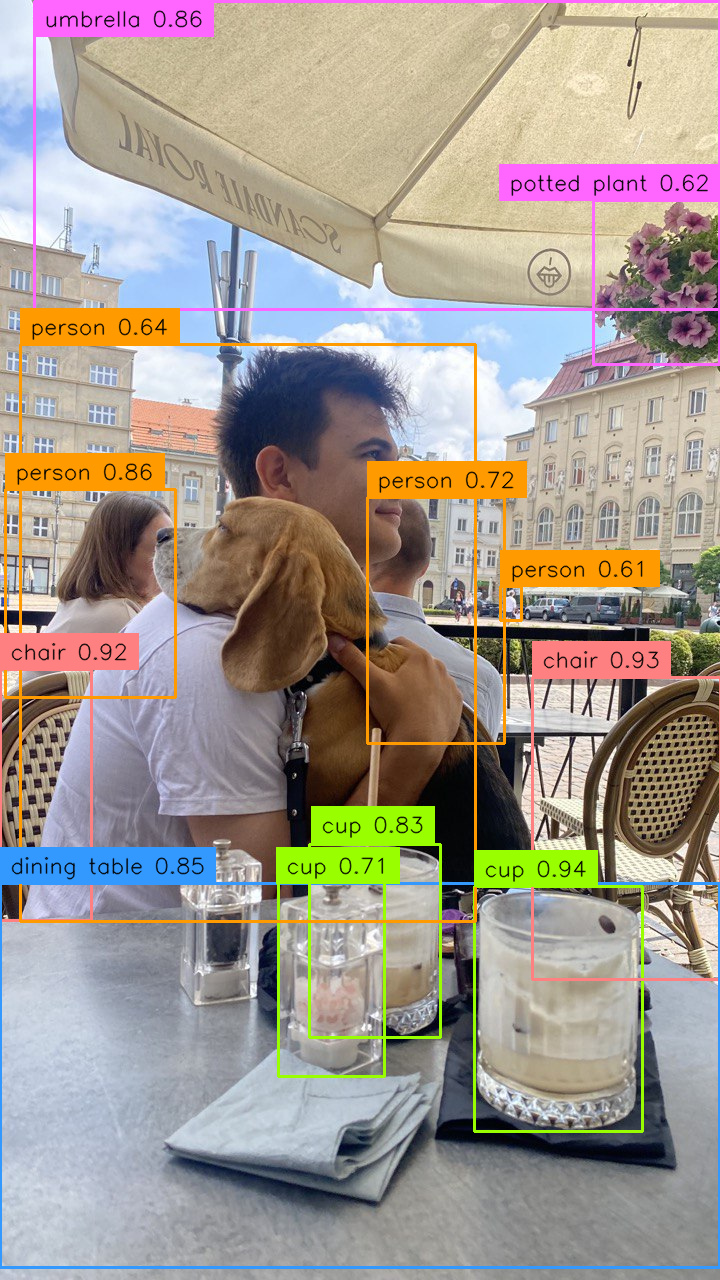

In [5]:
from rfdetr import RFDETRBase
from rfdetr.util.coco_classes import COCO_CLASSES
import supervision as sv
import numpy as np
from PIL import Image

image = Image.open("dog-2.jpeg")

model = RFDETRBase()
detections = model.predict(image, threshold=0.5)

color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])
text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True
)

labels = [
    f"{COCO_CLASSES[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()
annotated_image = bbox_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels)
annotated_image

## Change to RFDETRNano

[2026-04-21 11:05:22] [INFO] rf-detr - Downloading pretrained weights for rf-detr-nano.pth


rf-detr-nano.pth:   0%|          | 0.00/349M [00:00<?, ?iB/s]

[2026-04-21 11:05:46] [INFO] rf-detr - MD5 validation successful for rf-detr-nano.pth


[2026-04-21 11:05:46] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-21 11:05:46] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-21 11:05:47] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


[2026-04-21 11:05:48] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


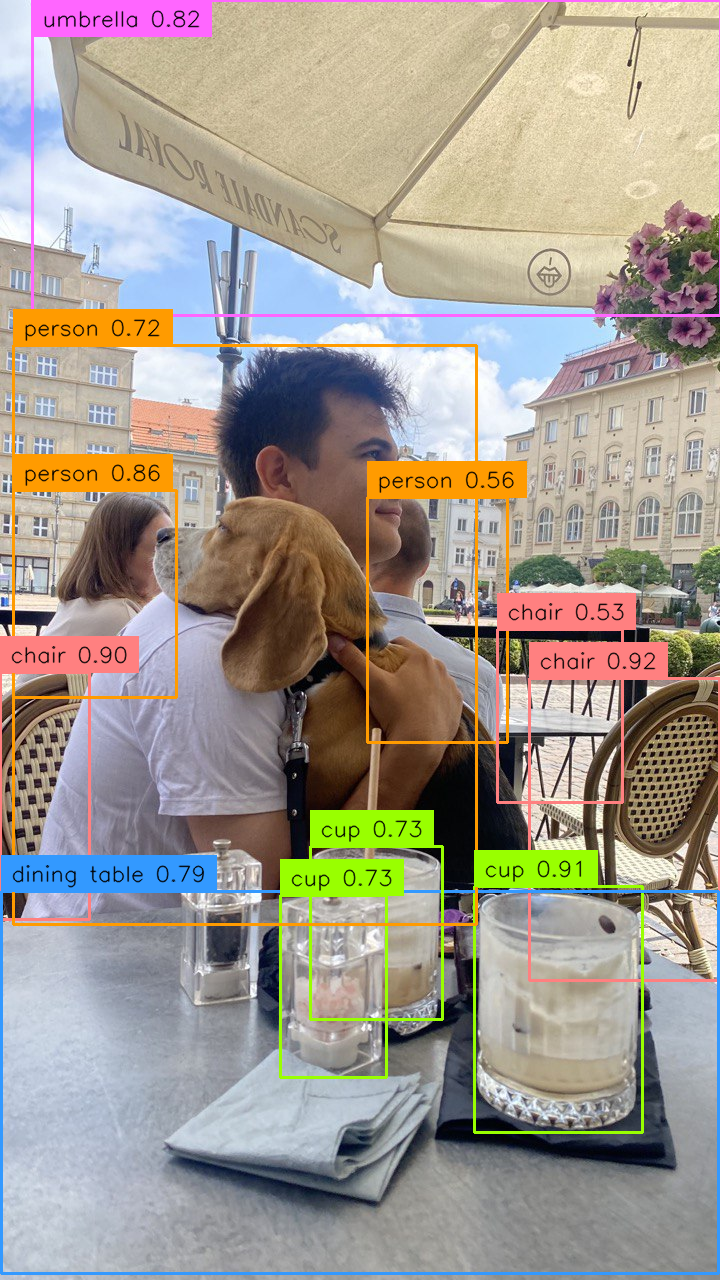

In [6]:
# Change the import from RFDETRBase to RFDETRNano
from rfdetr import RFDETRNano
from rfdetr.util.coco_classes import COCO_CLASSES
import supervision as sv
import numpy as np
from PIL import Image

image = Image.open("dog-2.jpeg")

# Instantiate the Nano model instead
model = RFDETRNano()
detections = model.predict(image, threshold=0.5)

color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])
text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True
)

labels = [
    f"{COCO_CLASSES[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()
annotated_image = bbox_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels)

# Display or save your image
annotated_image

##  Unzip Custom dataset Rock-Paprt-Scissors

In [6]:
# # Connect to Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
!pwd

/home/sagemaker-user/42028/Week9/RF-Detr


In [12]:
  # Upload and Unzip the Rock Paper Scissor Dataset on your Google Drive
  path_to_dataset = "RockPaperScissors-coco-reduced.zip"
  # %cd "/content/drive/MyDrive/Week9/" # UPDATE The path to the Week9 Folder
  !unzip {path_to_dataset}

Archive:  RockPaperScissors-coco-reduced.zip
   creating: train/
  inflating: train/0037_png.rf.6231d8fc3fe6083092067e96ac3cd715.jpg  
  inflating: train/0098_png.rf.e8204ac2df5ddc983871216ed8d2de00.jpg  
  inflating: train/0252_png.rf.3b1e7f3120a0c568624b7f25d9b7c366.jpg  
  inflating: train/060630_imaginaire_salle_4_jpg.rf.3416fc53183500c32bad551d2041a9d2.jpg  
  inflating: train/20220216_220837_jpg.rf.3536c6ae770b0bcf63f8b3d81955db3d.jpg  
  inflating: train/20220216_221828_jpg.rf.33ed05a2db5ac909c523125b5a127c78.jpg  
  inflating: train/20220216_222117_jpg.rf.d740fefce5785e5cf171ff7c09e983c1.jpg  
  inflating: train/20220216_222203_jpg.rf.af20024d775cdf349d3d3bdfd50946dd.jpg  
  inflating: train/20220216_223200_jpg.rf.28733dcc628d4152b1e892807921e3e9.jpg  
  inflating: train/20220216_223218_jpg.rf.aaa9c4d056940daca30a3a480b8d2cf9.jpg  
  inflating: train/20220216_223236_jpg.rf.825d5dca2a279a7b51e56cedd20935d2.jpg  
  inflating: train/20220216_223304_jpg.rf.fad7f5d4aadfe68aaf591d094

## Train RF-DETR on custom dataset

### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. For example, on powerful GPUs like the A100, set `batch_size=16` and `grad_accum_steps=1`. On smaller GPUs like the T4, use `batch_size=4` and `grad_accum_steps=4`. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

### Train with multiple GPUs

You can fine-tune RF-DETR on multiple GPUs using PyTorch’s Distributed Data Parallel (DDP). Create a `main.py` script that initializes your model and calls `.train()` as usual than run it in terminal.

```bash
python -m torch.distributed.launch \
    --nproc_per_node=8 \
    --use_env \
    main.py
```

Replace `8` in the `--nproc_per_node argument` with the number of GPUs you want to use. This approach creates one training process per GPU and splits the workload automatically. Note that your effective batch size is multiplied by the number of GPUs, so you may need to adjust your `batch_size` and `grad_accum_steps` to maintain the same overall batch size.

In [13]:
dataset_path="." # Change the Path to YOUR GOOGLE DRIVE FOLDER

In [14]:
ls

 RockPaperScissors-coco-reduced.zip             dog-3.jpeg         test/
'Week9-Part-2-Object detection-RF-DETR.ipynb'   rf-detr-base.pth   train/
 dog-2.jpeg                                     rf-detr-nano.pth   valid/


In [4]:
# from rfdetr import RFDETRBase

# model = RFDETRBase()

# # CHANGE THE BATCH SIZE BASED ON THE GPU INSTANCE USED, FOR T4 Use 4 (It is going to be very slow ~1hr per epoch!)
# # EXAMPLE Settings for model training : model.train(dataset_dir=dataset_path, epochs=15, batch_size=16, grad_accum_steps=1, lr=1e-4)
# model.train(dataset_dir=dataset_path, epochs=<ADD NO of EPOCHS>, batch_size=<ADD BATCH SIZE>, grad_accum_steps=1, lr=1e-4)

In [15]:
import json
import os

# Standard Roboflow COCO annotation filenames
splits = ["train", "valid", "test"]
annotation_filename = "_annotations.coco.json" 

for split in splits:
    file_path = os.path.join(split, annotation_filename)
    
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            data = json.load(f)
            
        print(f"--- {split.upper()} SPLIT ---")
        print(f"Images:      {len(data.get('images', []))}")
        print(f"Annotations: {len(data.get('annotations', []))}")
        print(f"Categories:  {len(data.get('categories', []))}")
        print(f"Classes:     {[cat['name'] for cat in data.get('categories', [])]}")
        
        # Peek at the first annotation to see the exact bounding box format
        if len(data.get('annotations', [])) > 0:
            first_bbox = data['annotations'][0]['bbox']
            print(f"BBox format: {first_bbox} [x_min, y_min, width, height]")
        print("\n")
    else:
        print(f"Could not find {file_path}. Use 'ls {split}/' to check the exact JSON filename.")

--- TRAIN SPLIT ---
Images:      576
Annotations: 400
Categories:  4
Classes:     ['rock-paper-scissors', 'Paper', 'Rock', 'Scissors']
BBox format: [30, 221, 458.5, 372.5] [x_min, y_min, width, height]


--- VALID SPLIT ---
Images:      304
Annotations: 204
Categories:  4
Classes:     ['rock-paper-scissors', 'Paper', 'Rock', 'Scissors']
BBox format: [131, 40, 146, 194] [x_min, y_min, width, height]


--- TEST SPLIT ---
Images:      304
Annotations: 204
Categories:  4
Classes:     ['rock-paper-scissors', 'Paper', 'Rock', 'Scissors']
BBox format: [131, 40, 146, 194] [x_min, y_min, width, height]




In [21]:
!pip install -U albumentations
!pip install faster-coco-eval
!pip install ipywidgets
!pip install pycocotools

  Using cached pycocotools-2.0.11-cp312-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (1.3 kB)


In [22]:
from rfdetr import RFDETRNano
dataset_path = "."

# Initialize the lightest model (Nano, ~30.5M parameters)
model = RFDETRNano()


model.train(
    dataset_dir=dataset_path, 
    epochs=30,              # Drop from 15 to 3. Enough to see the loss go down!
    batch_size=4,          # Nano is small, so try 8. If you get an OOM error, drop it back to 4.
    grad_accum_steps=4,    # 8 x 2 = 16 (Maintains your optimal effective batch size)
    lr=1e-4,
    enable_progress_bar=True,  # Turns off the broken UI bar
    log_every_n_steps=1     # Prints a text log every 10 batches
)

[2026-04-21 11:47:49] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


[2026-04-21 11:47:49] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-21 11:47:49] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-21 11:47:50] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


[2026-04-21 11:47:51] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-21 11:47:51] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-21 11:47:52] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


...

Trainable params: 30.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.2 M                                                                                               
Total estimated model params size (MB): 120                                                                        
Modules in train mode: 449                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[2026-04-21 11:47:56] [INFO] rf-detr - Best EMA mAP improved to 0.0004 (epoch 0)
[2026-04-21 11:49:47] [INFO] rf-detr - Best regular mAP saved to /home/sagemaker-user/42028/Week9/RF-Detr/output/checkpoint_best_regular.pth (epoch 0)
[2026-04-21 11:49:48] [INFO] rf-detr - Best EMA mAP improved to 0.3276 (epoch 0)
[2026-04-21 11:51:40] [INFO] rf-detr - Best regular mAP saved to /home/sagemaker-user/42028/Week9/RF-Detr/output/checkpoint_best_regular.pth (epoch 1)
[2026-04-21 11:51:41] [INFO] rf-detr - Best EMA mAP improved to 0.5119 (epoch 1)
[2026-04-21 11:53:31] [INFO] rf-detr - Best regular mAP saved to /home/sagemaker-user/42028/Week9/RF-Detr/output/checkpoint_best_regular.pth (epoch 2)
[2026-04-21 11:53:32] [INFO] rf-detr - Best EMA mAP improved to 0.5605 (epoch 2)
[2026-04-21 11:55:24] [INFO] rf-detr - Best regular mAP saved to /home/sagemaker-user/42028/Week9/RF-Detr/output/checkpoint_best_regular.pth (epoch 3)
[2026-04-21 11:55:25] [INFO] rf-detr - Best EMA mAP improved to 0.5874 (

`Trainer.fit` stopped: `max_epochs=30` reached.


[2026-04-21 12:44:06] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.6854, ema=0.6983)


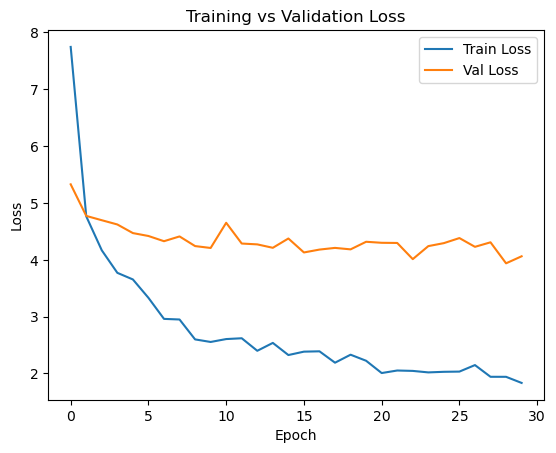

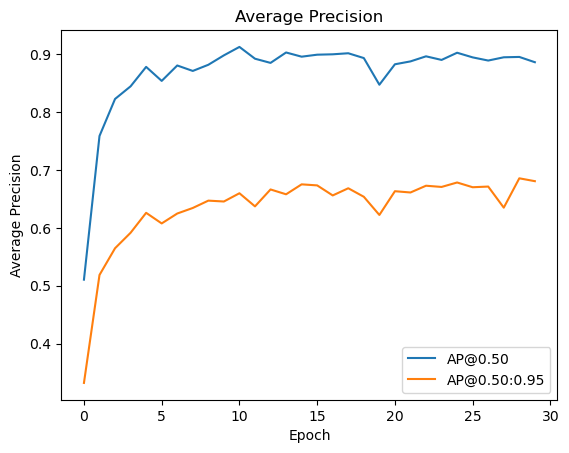

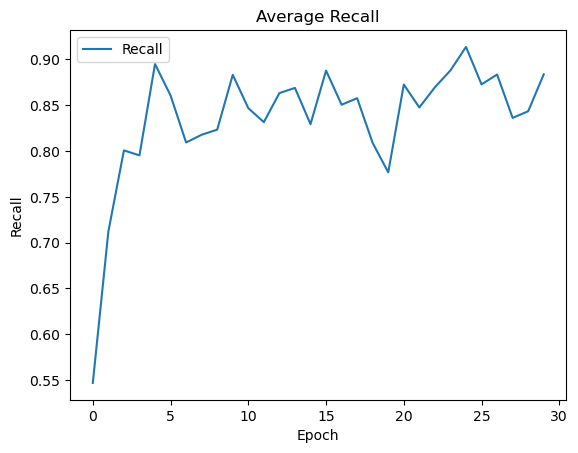

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./output/metrics.csv')
df = df.dropna(subset=["epoch"])

epoch_df = df.groupby("epoch").mean(numeric_only=True).reset_index()

plt.figure()
plt.plot(epoch_df["epoch"], epoch_df["train/loss"], label="Train Loss")
plt.plot(epoch_df["epoch"], epoch_df["val/loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


plt.figure()
plt.plot(epoch_df["epoch"], epoch_df["val/mAP_50"], label="AP@0.50")
plt.plot(epoch_df["epoch"], epoch_df["val/mAP_50_95"], label="AP@0.50:0.95")
plt.xlabel("Epoch")
plt.ylabel("Average Precision")
plt.title("Average Precision")
plt.legend()
plt.show()


plt.figure()
plt.plot(epoch_df["epoch"], epoch_df["val/recall"], label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Average Recall")
plt.legend()
plt.show()

## Run inference with fine-tuned model

In [4]:
# !pip install supervision

In [24]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path="./test", # UPDATE The path to the Week9/test dataset output Folder
    annotations_path="./test/_annotations.coco.json", # UPDATE The path to the Week9/test dataset output Folder for the annotation JSON file
)

[2026-04-21 13:01:10] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


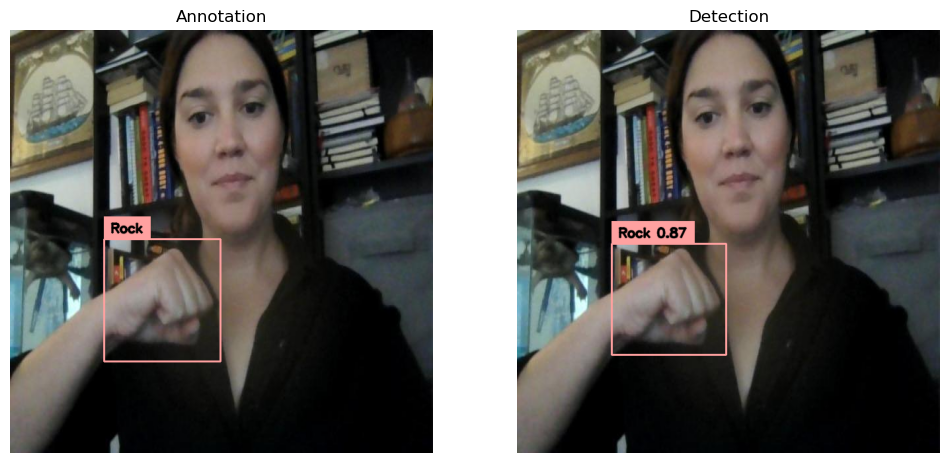

In [25]:
# Run inference on Single Image
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[3]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

bbox_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_thickness=thickness,
    smart_position=True)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

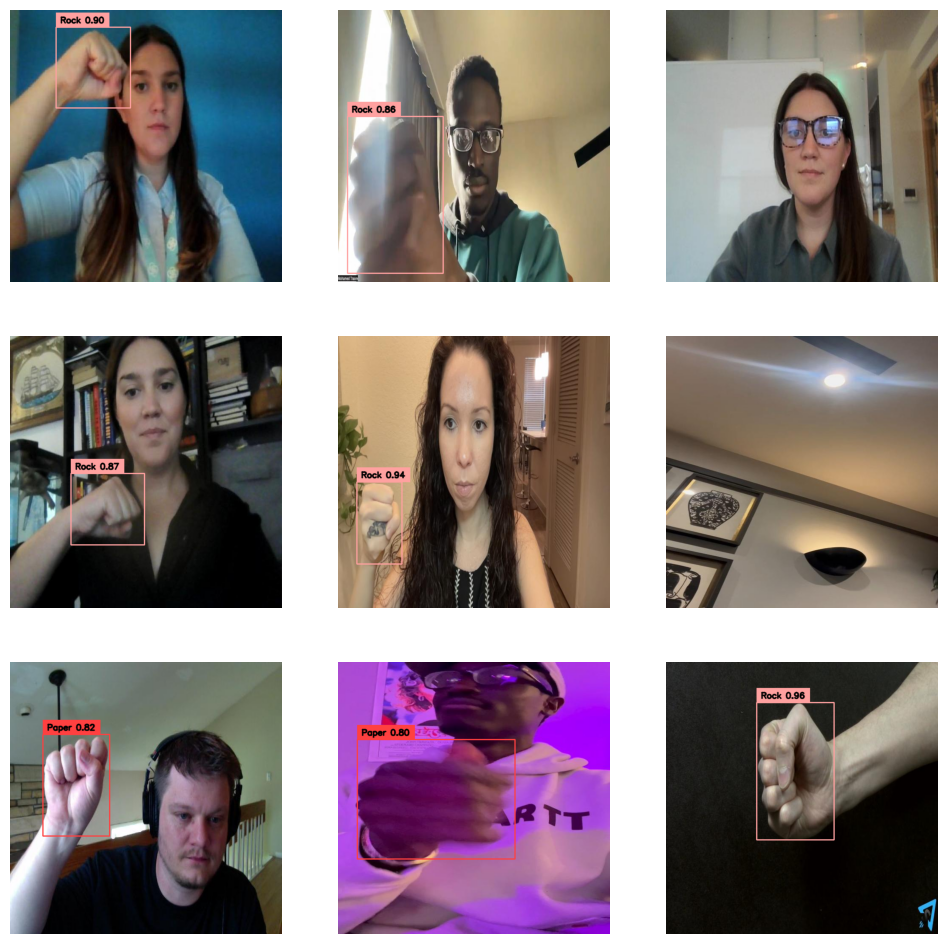

In [26]:
# Run inference on Multiple Images
import supervision as sv
from rfdetr import RFDETRBase
from PIL import Image

detections_images = []

for i in range(9):
    path, image, annotations = ds[i]
    image = Image.open(path)

    detections = model.predict(image, threshold=0.5)

    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
    thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

    bbox_annotator = sv.BoxAnnotator(thickness=thickness)
    label_annotator = sv.LabelAnnotator(
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        text_thickness=thickness,
        smart_position=True)

    detections_labels = [
        f"{ds.classes[class_id]} {confidence:.2f}"
        for class_id, confidence
        in zip(detections.class_id, detections.confidence)
    ]

    detections_image = image.copy()
    detections_image = bbox_annotator.annotate(detections_image, detections)
    detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

    detections_images.append(detections_image)

sv.plot_images_grid(images=detections_images, grid_size=(3, 3), size=(12, 12))

## Evaluate fine-tuned model

In [27]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0.5)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 304/304 [00:10<00:00, 29.32it/s]


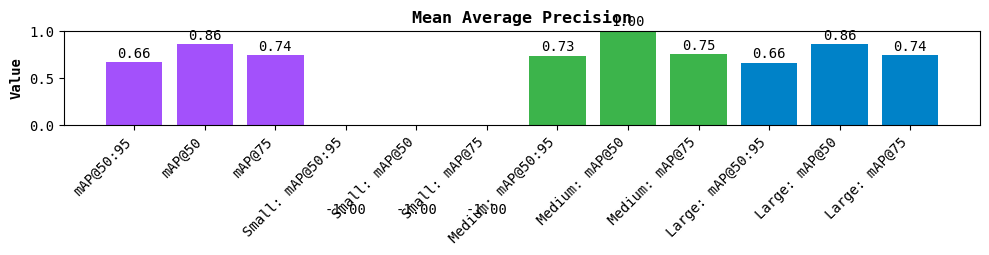

In [28]:
# Plot mAPs using COCO Metrics
for p in predictions:
    if 'source_shape' in p.data:
        del p.data['source_shape']

for t in targets:
    if 'source_shape' in t.data:
        del t.data['source_shape']

map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()

map_result.plot()

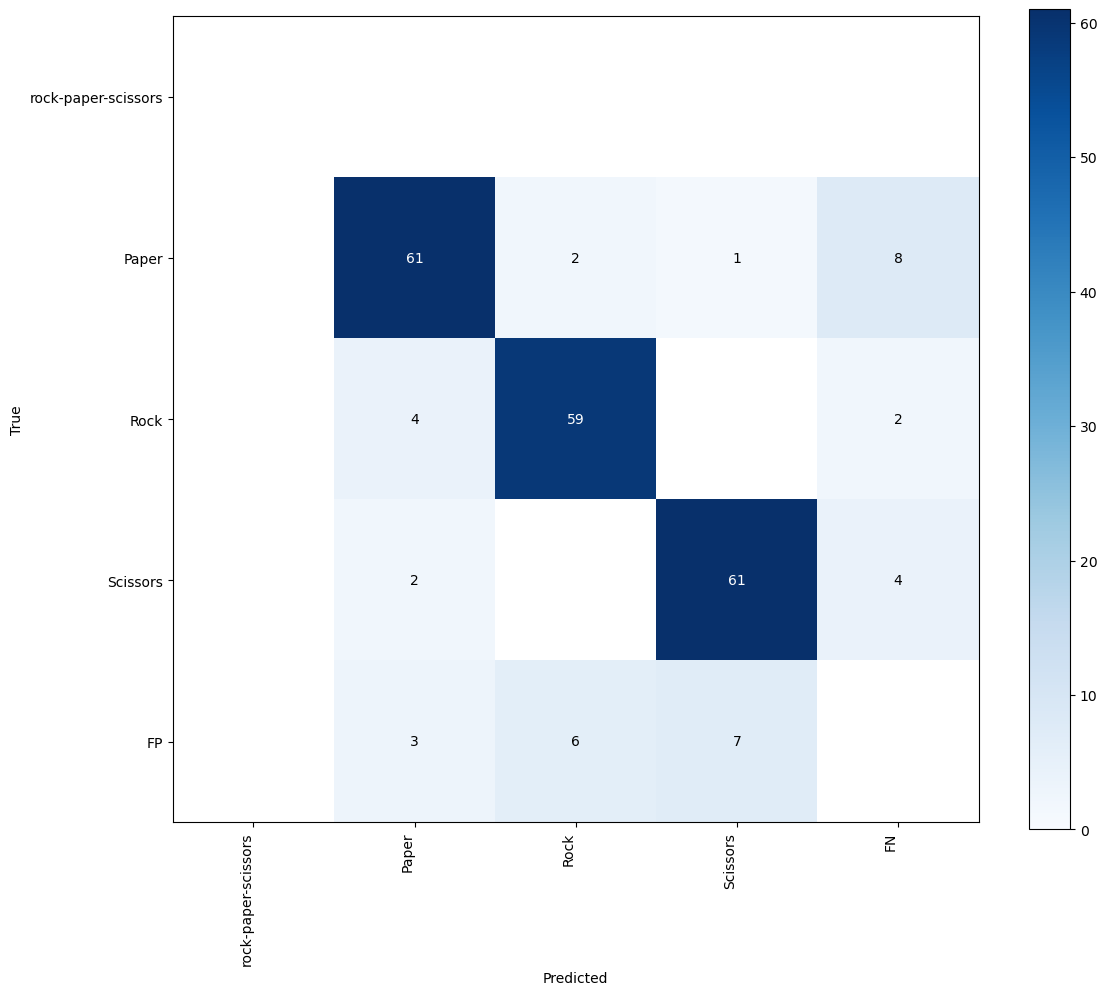

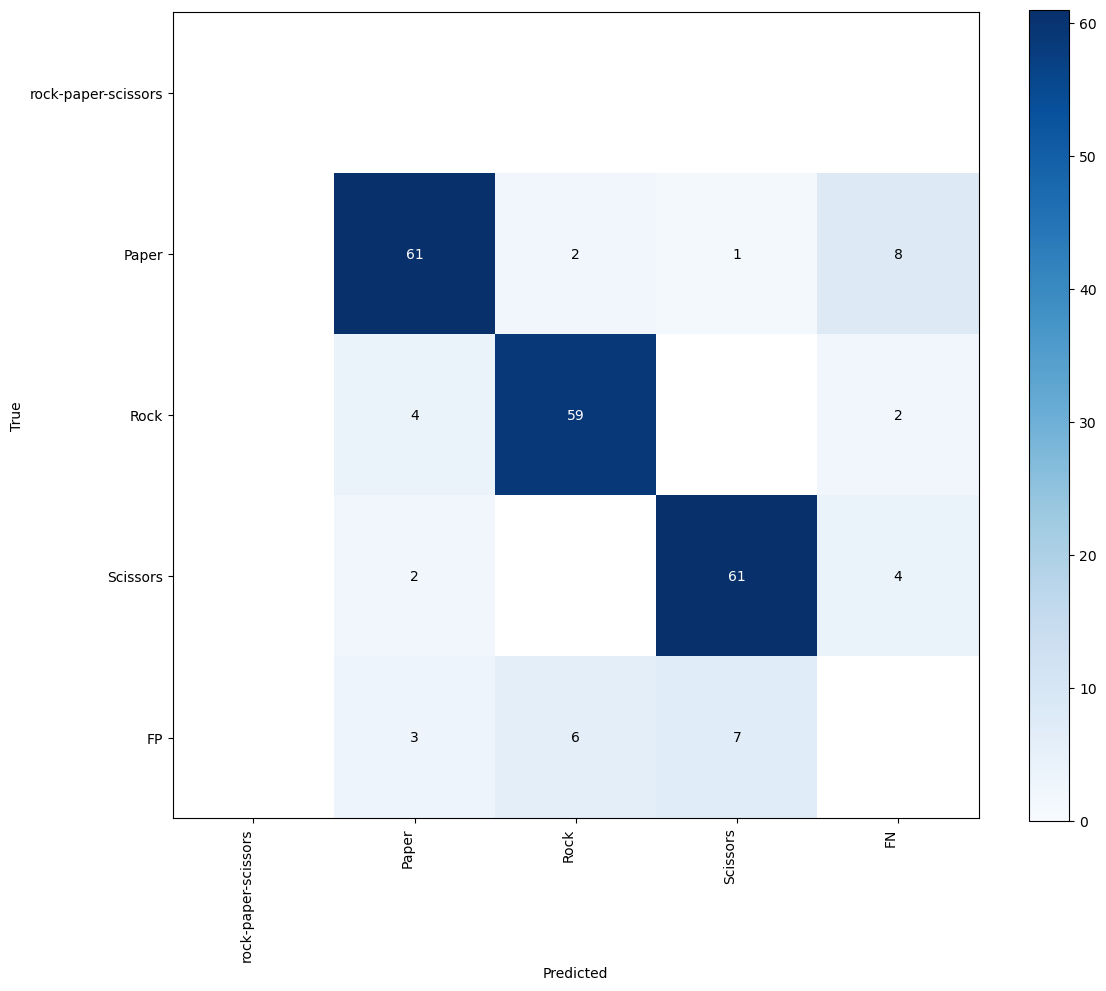

In [29]:
# Plot Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds.classes
)

confusion_matrix.plot()